In [6]:
import numpy as np
import pandas as pd
# import generate_exchangeable, martingale_plug_in
from scenarios_and_methods import (
    generate_two_gaussian_abrupt_shift, generate_two_gaussian_slow_shift,
    risk_monitoring, simple_mixture_martingale_test, plugin_martingale_test
)

# Perform tests

In [7]:
scenarios_dict = {
    # "exchangeable": generate_exchangeable,
    "two_gaussian_abrupt_shift": generate_two_gaussian_abrupt_shift,
    "generate_two_gaussian_slow_shift": generate_two_gaussian_slow_shift,
}

methods_dict = {
    "plugin_martingale": plugin_martingale_test,
    "simple_mixture_martingale": simple_mixture_martingale_test,
    'risk_monitoring': risk_monitoring,
}

n_samples = 1000
result_list=[]
for scenario_name, generate_data in scenarios_dict.items():
    is_exchangeable_ground_truth, X_to_test, y_to_test, X_train, y_train = generate_data(n_samples=n_samples)

    for method_name, method in methods_dict.items():
        is_exchangeable, threshold, test_stat = method(
            X_to_test=X_to_test,
            y_to_test=y_to_test,
            X_train=X_train,
            y_train=y_train
        )
        df_ = pd.DataFrame({
            "scenario": scenario_name,
            "method": method_name, 
            "is_exchangeable_ground_truth": is_exchangeable_ground_truth,
            "is_exchangeable": is_exchangeable,
            "n": np.arange(1, n_samples+1),
            "test_stat": test_stat,
            "threshold":threshold,
        })
        result_list.append(df_)

df = pd.concat(result_list)

Test accuracy: 0.993
Test accuracy: 0.980


# Show results

In [8]:
# Prepare pivot table for summary
summary_df = df.groupby(['scenario', 'method']).agg({
    'is_exchangeable_ground_truth': 'first',
    'is_exchangeable': 'first'
}).reset_index()

# For each scenario, collect ground truth once
gt_df = summary_df[['scenario', 'is_exchangeable_ground_truth']].drop_duplicates()
gt_df = gt_df.rename(columns={'is_exchangeable_ground_truth': 'ground_truth'})

# Pivot the methods
method_df = summary_df.pivot(index='scenario', columns='method', values='is_exchangeable')

# Join with the ground truth
final_df = method_df.join(gt_df.set_index('scenario'))

# Reorder columns to have ground_truth first, then methods
cols = ['ground_truth'] + [col for col in final_df.columns if col != 'ground_truth']
final_df = final_df[cols]

# Convert bools to int (0: not exchangeable, 1: exchangeable)
final_df = final_df.astype(int)

display(final_df)

,ground_truth,plugin_martingale,risk_monitoring,simple_mixture_martingale
scenario,,,,
generate_two_gaussian_slow_shift,0,1,0,0
two_gaussian_abrupt_shift,0,0,0,1


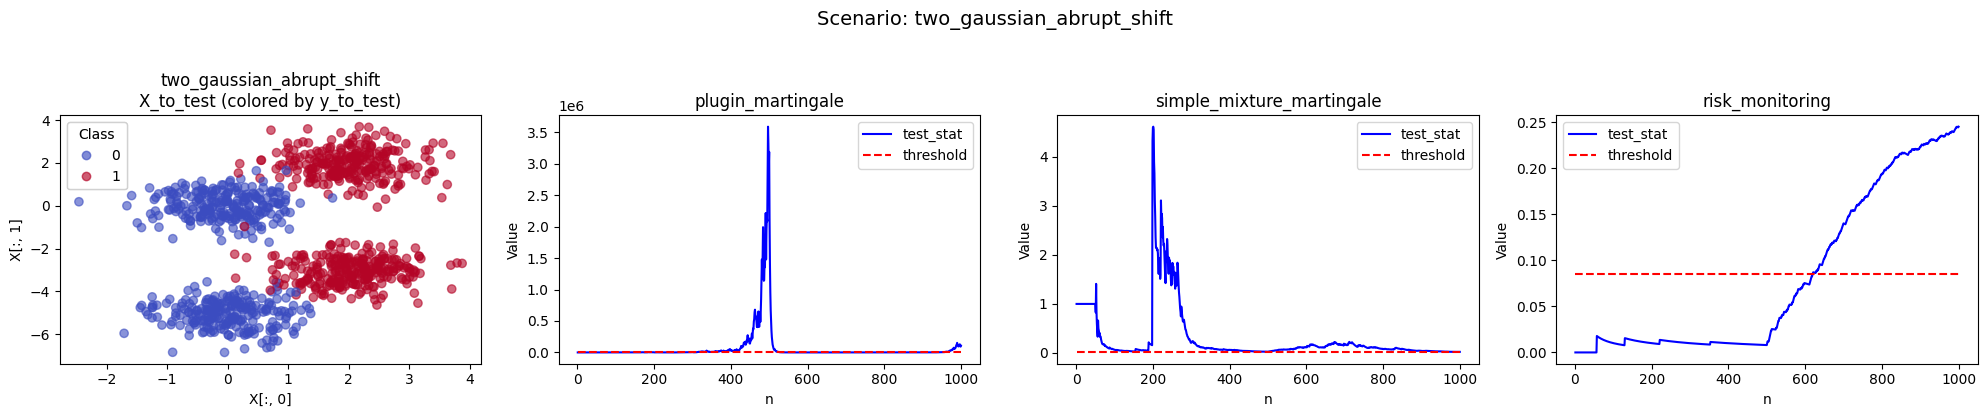

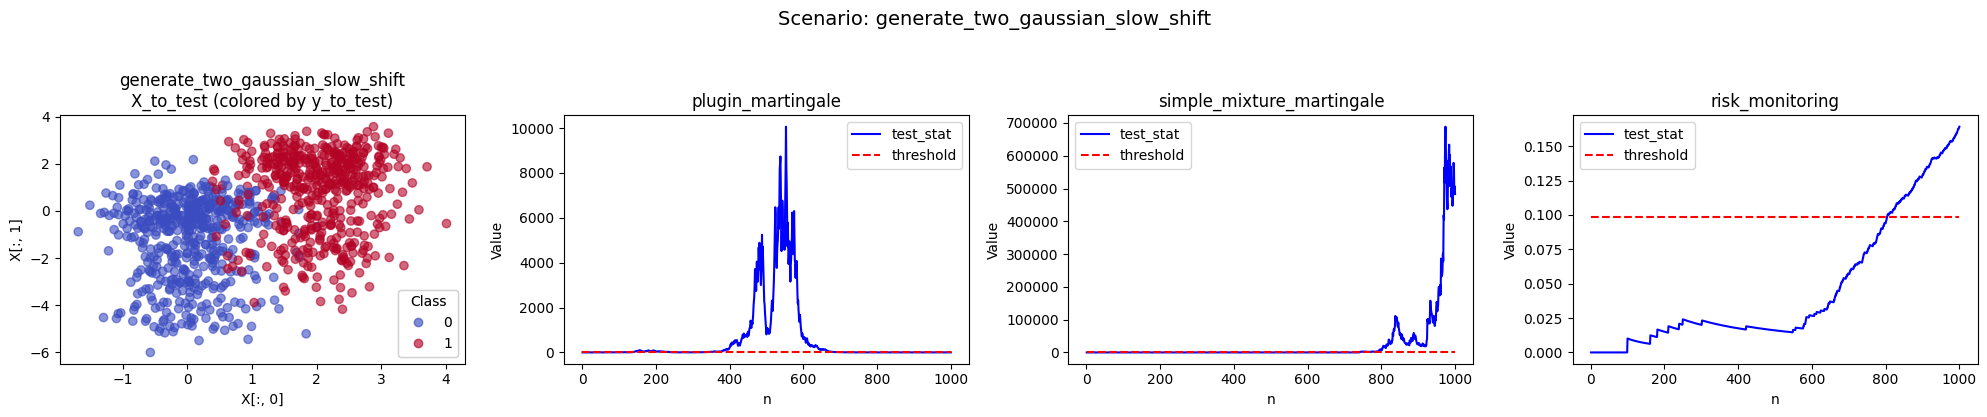

In [9]:
import matplotlib.pyplot as plt

# For plotting, we use scenarios_dict and methods_dict below
# scenarios_dict: {scenario_name: scenario_func}
# methods_dict: {method_name: method_func}

for scenario_name, scenario_func in scenarios_dict.items():
    # Regenerate data for the scenario (with default/random_state for reproducibility)
    res = scenario_func()
    if len(res) == 5:
        is_exchangeable_ground_truth, X_to_test, y_to_test, X_train, y_train = res
    else:
        # fallback, skip plotting
        continue

    df_scenario = df[df["scenario"] == scenario_name]
    # Find method names for this scenario
    method_names = df_scenario["method"].unique()
    
    n_rows = 1
    n_cols = 1 + len(method_names)
    fig, axes = plt.subplots(
        nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4), squeeze=False
    )
    # Plot scenario data in the first column (scatter X_to_test, color by y_to_test)
    ax = axes[0, 0]
    if X_to_test.shape[1] == 2:
        scatter = ax.scatter(X_to_test[:, 0], X_to_test[:, 1], c=y_to_test, cmap='coolwarm', alpha=0.6)
        legend1 = ax.legend(*scatter.legend_elements(), title="Class")
        ax.add_artist(legend1)
    else:
        # Too many dims, just plot first two
        ax.scatter(X_to_test[:, 0], np.zeros_like(X_to_test[:, 0]), c=y_to_test, cmap='coolwarm', alpha=0.6)
    ax.set_title(f"{scenario_name}\nX_to_test (colored by y_to_test)")
    ax.set_xlabel("X[:, 0]")
    if X_to_test.shape[1] > 1:
        ax.set_ylabel("X[:, 1]")
    else:
        ax.set_ylabel("")

    # Plot test_stat vs threshold for each method
    for j, method_name in enumerate(method_names, start=1):
        ax = axes[0, j]
        df_method = df_scenario[df_scenario["method"] == method_name]
        n = df_method["n"].values
        test_stat = df_method["test_stat"].values
        threshold = df_method["threshold"].values

        # Plot test_stat and threshold as lines
        ax.plot(n, test_stat, label="test_stat", color="blue")
        ax.plot(n, threshold, label="threshold", color="red", linestyle="--")
        ax.set_title(f"{method_name}")
        ax.set_xlabel("n")
        ax.set_ylabel("Value")
        ax.legend()
    plt.suptitle(f"Scenario: {scenario_name}", fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()